# EDA - CBBData

cbbdata is an R package designed for college basketball statistics. It simplifies the process of accessing and analyzing a wealth of college basketball data, making it more efficient and user-friendly. Database is updated every 15 minutes during the season.
Key features:
- detailed box scores and advanced metrics for players and teams dating back to 2008
- the latest NET rankings
- Simulate any matchup, real or otherwise, using game prediction feature, powered by Barttorvik


https://cbbdata.aweatherman.com/#barttorvik

In [1]:
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt

import subprocess
import tempfile, os



### Setup

In [2]:
load_dotenv()

username = os.getenv("CBB_USERNAME")
password = os.getenv("CBB_PASSWORD")

r_script = f"""
library(cbbdata)
cbd_login(username = '{username}', password = '{password}')
"""

result = subprocess.run(["Rscript", "-e", r_script], capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("STDERR:", result.stderr)

API Key set!


### Load data
2024 Year-end ratings (cbd_torvik_ratings)

dictionary: https://github.com/andreweatherman/cbbdata/blob/main/data/dictionary_torvik_ratings.csv

In [23]:
tmp = tempfile.mktemp(suffix=".csv")

r_script = f"""
suppressMessages({{
    library(cbbdata)
    df <- cbd_torvik_ratings(year = 2024)
    write.csv(df, '{tmp}', row.names = FALSE)
}})
"""

result = subprocess.run(["Rscript", "-e", r_script], capture_output=True, text=True)

if result.returncode != 0:
    print("Error:", result.stderr)
else:
    df = pd.read_csv(tmp)
    os.remove(tmp)
    print(df.shape)
    df.head()

(362, 19)


In [24]:
df.head()

,team,conf,barthag,barthag_rk,adj_o,adj_o_rk,adj_d,adj_d_rk,adj_t,adj_t_rk,wab,nc_elite_sos,nc_fut_sos,nc_cur_sos,ov_elite_sos,ov_fut_sos,ov_cur_sos,seed,year
0,Connecticut,BE,0.979889,1,127.966,1,91.2711,4,64.6459,327,11.237196,24,0.4617,0.4617,36,0.6972,0.6972,1.0,2024
1,Houston,B12,0.976632,2,119.642,15,86.4804,1,63.4388,349,9.953168,16,0.4976,0.4976,33,0.7131,0.7131,1.0,2024
2,Purdue,B10,0.964935,3,126.020,3,94.4613,15,67.1072,211,10.625227,32,0.6686,0.6686,37,0.7670,0.7670,1.0,2024
3,Auburn,SEC,0.953417,4,121.011,10,93.0723,7,69.9722,56,5.211373,16,0.5311,0.5311,28,0.6889,0.6889,4.0,2024
4,Iowa St.,B12,0.951709,5,113.612,53,87.6690,2,67.3506,193,6.274264,11,0.3747,0.3747,32,0.6722,0.6722,2.0,2024


In [25]:
df.columns

Index(['team', 'conf', 'barthag', 'barthag_rk', 'adj_o', 'adj_o_rk', 'adj_d',
       'adj_d_rk', 'adj_t', 'adj_t_rk', 'wab', 'nc_elite_sos', 'nc_fut_sos',
       'nc_cur_sos', 'ov_elite_sos', 'ov_fut_sos', 'ov_cur_sos', 'seed',
       'year'],
      dtype='object')

In [26]:
df.describe()

,barthag,barthag_rk,adj_o,adj_o_rk,adj_d,adj_d_rk,adj_t,adj_t_rk,wab,nc_elite_sos,nc_fut_sos,nc_cur_sos,ov_elite_sos,ov_fut_sos,ov_cur_sos,seed,year
count,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,362.000000,68.000000,362.0
mean,0.492300,181.500000,105.476577,181.500000,105.476515,181.500000,67.616038,181.500000,-8.357748,16.121547,0.442125,0.442125,16.908840,0.481255,0.481255,8.764706,2024.0
std,0.255354,104.644637,7.531205,104.644637,5.981302,104.644637,2.429955,104.644637,6.880610,5.915998,0.090137,0.090137,8.612622,0.140295,0.140295,4.687607,0.0
min,0.031142,1.000000,85.344900,1.000000,86.480400,1.000000,60.159000,1.000000,-24.771286,5.000000,0.249800,0.249800,5.000000,0.259800,0.259800,1.000000,2024.0
25%,0.285917,91.250000,100.094000,91.250000,101.084750,91.250000,65.935025,91.250000,-13.071674,12.000000,0.378225,0.378225,11.000000,0.366025,0.366025,5.000000,2024.0
50%,0.458093,181.500000,105.095000,181.500000,105.722500,181.500000,67.486050,181.500000,-9.198718,15.000000,0.436850,0.436850,13.000000,0.442800,0.442800,9.000000,2024.0
75%,0.724819,271.750000,110.434000,271.750000,110.113750,271.750000,69.020100,271.750000,-3.516156,19.000000,0.495125,0.495125,21.750000,0.599150,0.599150,13.000000,2024.0
max,0.979889,362.000000,127.966000,362.000000,121.094000,362.000000,75.102800,362.000000,11.237196,40.000000,0.722300,0.722300,38.000000,0.771900,0.771900,16.000000,2024.0


In [27]:
df.isnull().sum()

team              0
conf              0
barthag           0
barthag_rk        0
adj_o             0
adj_o_rk          0
adj_d             0
adj_d_rk          0
adj_t             0
adj_t_rk          0
wab               0
nc_elite_sos      0
nc_fut_sos        0
nc_cur_sos        0
ov_elite_sos      0
ov_fut_sos        0
ov_cur_sos        0
seed            294
year              0
dtype: int64

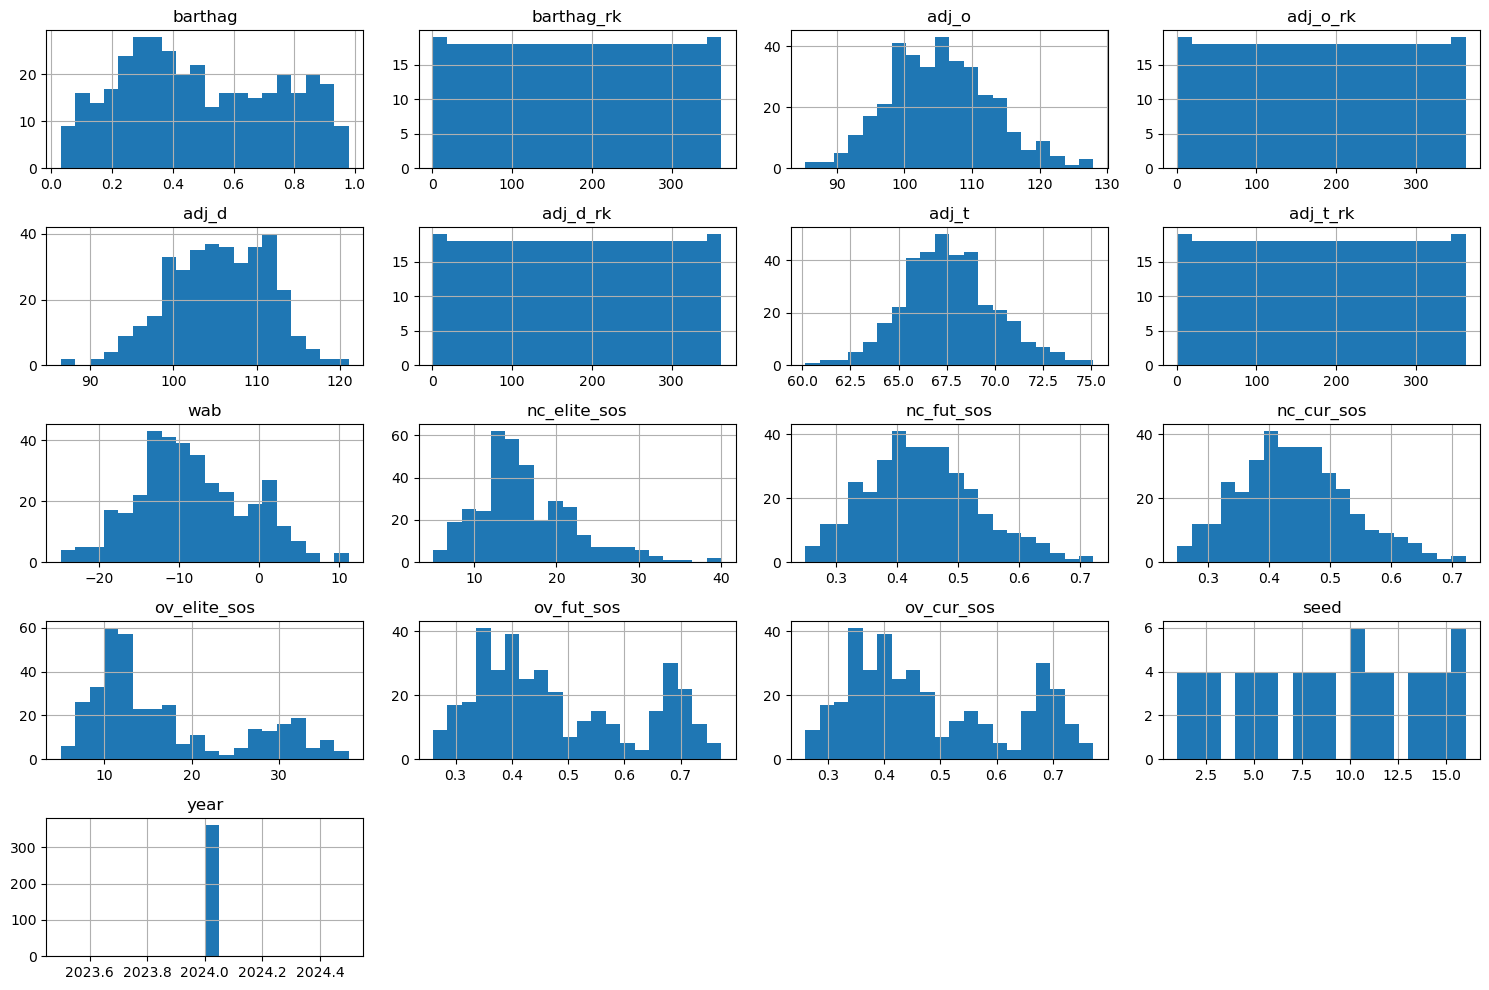

In [28]:
df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

### Player data
Season averages (cbd_torvik_player_season)

In [29]:
tmp = tempfile.mktemp(suffix=".csv")

r_script = f"""
suppressMessages({{
    library(cbbdata)
    df <- cbd_torvik_player_season(year = 2024)
    write.csv(df, '{tmp}', row.names = FALSE)
}})
"""

result = subprocess.run(["Rscript", "-e", r_script], capture_output=True, text=True)
if result.returncode != 0:
    print("Error:", result.stderr)
else:
    df_player = pd.read_csv(tmp)
    os.remove(tmp)
    print(df_player.shape)
    df_player.head()


(5002, 65)


In [30]:
df_player.head()

,player,pos,exp,num,hgt,team,conf,g,min,mpg,...,ast,to,blk,stl,ftr,pfr,rec,pick,fga,fg_pct
0,DeJuan Clayton,Wing G,Sr,13.0,6-2,Manhattan,MAAC,2,4.3,25.0000,...,28.2,20.8,0.0,0.0,36.8,1.6,NaN,NaN,19,0.473684
1,Seth Towns,Stretch 4,Sr,31.0,6-9,Howard,MEAC,30,73.4,32.3750,...,14.9,14.9,1.4,1.8,41.0,3.7,74.4,NaN,332,0.358434
2,Terrence Lewis,Wing G,Sr,24.0,6-6,Grambling St.,SWAC,20,26.9,17.7391,...,4.9,15.0,1.2,1.5,13.9,3.5,76.4,NaN,115,0.530435
3,Austin Williams,Wing G,Sr,24.0,6-4,Rutgers,B10,26,32.1,15.8846,...,8.0,23.8,2.0,1.7,43.2,4.1,NaN,NaN,88,0.465909
4,Avery Wilson,Wing G,Sr,1.0,6-4,Southeastern Louisiana,Slnd,29,27.8,11.5938,...,13.2,23.4,0.8,1.9,63.9,5.3,49.0,NaN,61,0.393443


In [12]:
tmp = tempfile.mktemp(suffix=".csv")

r_script = f"""
suppressMessages({{
    library(cbbdata)
    df <- cbd_torvik_player_game(year = 2024)
    write.csv(df, '{tmp}', row.names = FALSE)
}})
"""

result = subprocess.run(["Rscript", "-e", r_script], capture_output=True, text=True)
if result.returncode != 0:
    print("Error:", result.stderr)
else:
    df_player = pd.read_csv(tmp)
    os.remove(tmp)
    print(df_player.shape)
    df_player.head()


(0, 52)


In [13]:
r_script = f"""
library(cbbdata)
library(httr2)
library(purrr)
cbd_login(username = '{username}', password = '{password}')
for (yr in 2022:2026) {{
    df <- cbd_torvik_player_game(year = yr)
    cat('year', yr, 'nrow:', nrow(df), '\\n')
}}
"""

result = subprocess.run(["Rscript", "-e", r_script], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)


API Key set!year 2022 nrow: 107926 
year 2023 nrow: 112744 
year 2024 nrow: 0 
year 2025 nrow: 114250 
year 2026 nrow: 0 

Warning message:
package ‘httr2’ was built under R version 4.4.3 
Warning message:
package ‘purrr’ was built under R version 4.4.3 

